# Einleitung

Multiple Lineare Regression für die Algorithmen

In Teil 1 wird das Model für jeden Algorithmus seperat trainiert

In Teil 2 wird das Model für alle Algorithmen trainiert



# Datenvorbereitung

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Hier werden nur die Ergebnisse für das Diabetes Experiemnt geladen
random_forest_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_RandomForest.csv'
xgb_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_XGB.csv'
logistic_regression_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_LogisticRegression.csv'
knn_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_KNN.csv'
gaussian_nb_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_GaussianNB.csv'
decision_tree_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_DecisionTree.csv'

In [3]:
import pandas as pd

random_forest_df = pd.read_csv(random_forest_data)
xgb_df = pd.read_csv(xgb_data)
logistic_regression_df = pd.read_csv(logistic_regression_data)
knn_df = pd.read_csv(knn_data)
gaussian_nb_df = pd.read_csv(gaussian_nb_data)
decision_tree_df = pd.read_csv(decision_tree_data)

In [4]:
# Definieren der Feature Typen
feature_types = {
    'Diabetes_binary': 'kategorisch',
    'HighBP': 'kategorisch',
    'HighChol': 'kategorisch',
    'CholCheck': 'kategorisch',
    'BMI': 'numerisch',
    'Smoker': 'kategorisch',
    'Stroke': 'kategorisch',
    'HeartDiseaseorAttack': 'kategorisch',
    'PhysActivity': 'kategorisch',
    'Fruits': 'kategorisch',
    'Veggies': 'kategorisch',
    'HvyAlcoholConsump': 'kategorisch',
    'AnyHealthcare': 'kategorisch',
    'NoDocbcCost': 'kategorisch',
    'GenHlth': 'numerisch',
    'MentHlth': 'numerisch',
    'PhysHlth': 'numerisch',
    'DiffWalk': 'kategorisch',
    'Sex': 'kategorisch',
    'Age': 'numerisch',
    'Education': 'numerisch',
    'Income': 'numerisch'
}

In [5]:
# Mappen der Features auf die Daten
dataframes = [random_forest_df, xgb_df, logistic_regression_df, knn_df, gaussian_nb_df, decision_tree_df]

for df in dataframes:
  df['num_num_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'numerisch'))
  df['num_cat_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'kategorisch'))

# Ermitteln, wie of ein feature vorgekommen ist

df['feature_names'] = df['feature_names'].str.split(', ')

feature_counts = {}

# Iteriere über jedes DataFrame in der Liste
for df in dataframes:
    df['feature_names'] = df['feature_names'].str.split(', ')
    for index, row in df.iterrows():
        features = row['feature_names']
        if isinstance(features, list):
            for feature in features:
                if feature in feature_counts:
                    feature_counts[feature] += 1
                else:
                    feature_counts[feature] = 1

In [6]:
# Hinzufügen von dem verwendeten Model
model_names = {
    'random_forest_df': "RandomForest",
    'xgb_df': "XGB",
    'logistic_regression_df': "LogisticRegression",
    'knn_df': "KNN",
    'gaussian_nb_df': "GaussianNB",
    'decision_tree_df': "DecisionTree"
}

for df_name, model_name in model_names.items():
    df = locals()[df_name]
    df.insert(0, 'model', model_name)

In [7]:
# Reduzieren der Eingabeparams für das Modell und Analyse
selected_columns = ['model', 'duration', 'emissions', 'emissions_rate', 'cpu_energy', 'ram_energy', 'energy_consumed', 'num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']

# löschen der anderen splaten
for df_name, model_name in model_names.items():
    df = locals()[df_name]

    columns_to_drop = [col for col in df.columns if col not in selected_columns]
    df.drop(columns=columns_to_drop, inplace=True)

# Datenanalyse

In [8]:
# Funktion, die die jeweiligen Diagramme erstellt
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_correlation_matrix(df):
    # Korrelationsmatrix
    correlation_matrix = df.corr()

    # Heatmap der Korrelationsmatrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Korrelationsmatrix')
    plt.show()

## Datenvisialisierung pro Model

### Random Forest

In [9]:
random_forest_df.describe()

,duration,emissions,emissions_rate,cpu_energy,ram_energy,energy_consumed,num_features,reduction_percentage,num_num_features,num_cat_features
count,1050.000000,1.050000e+03,1.050000e+03,1050.000000,1.050000e+03,1050.000000,1050.000000,1050.00000,1050.000000,1050.000000
mean,7.705046,7.446212e-05,9.661690e-06,0.000091,1.016121e-05,0.000101,11.000000,40.00000,3.628571,7.371429
std,5.937216,5.753484e-05,2.981533e-07,0.000070,7.836935e-06,0.000078,6.058186,28.29775,2.203893,4.096680
min,0.558839,4.002248e-07,3.118418e-08,0.000007,7.260410e-07,0.000007,1.000000,0.00000,0.000000,0.000000
25%,2.991155,2.867737e-05,9.666576e-06,0.000035,3.935076e-06,0.000039,6.000000,20.00000,2.000000,4.000000
50%,5.876694,5.648967e-05,9.677743e-06,0.000069,7.750941e-06,0.000077,11.000000,40.00000,4.000000,7.000000
75%,11.710368,1.131795e-04,9.683007e-06,0.000138,1.545320e-05,0.000154,16.000000,60.00000,6.000000,11.000000
max,24.747113,2.396518e-04,9.687116e-06,0.000292,3.265860e-05,0.000325,21.000000,80.00000,7.000000,14.000000


<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


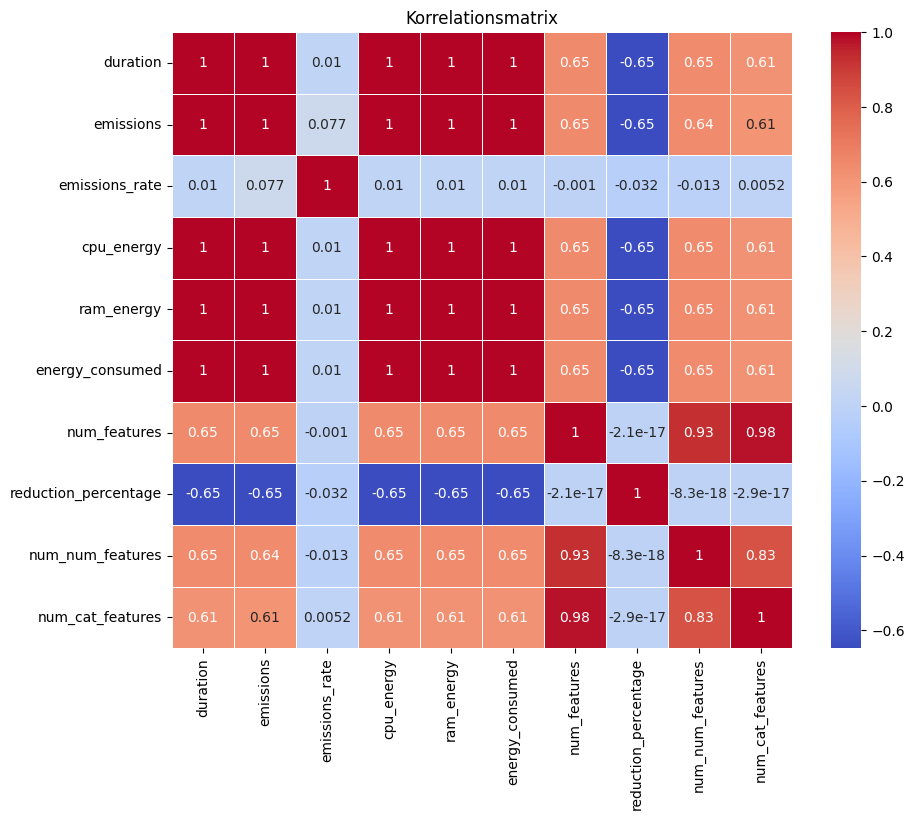

In [10]:
visualize_correlation_matrix(random_forest_df)

### XGB

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


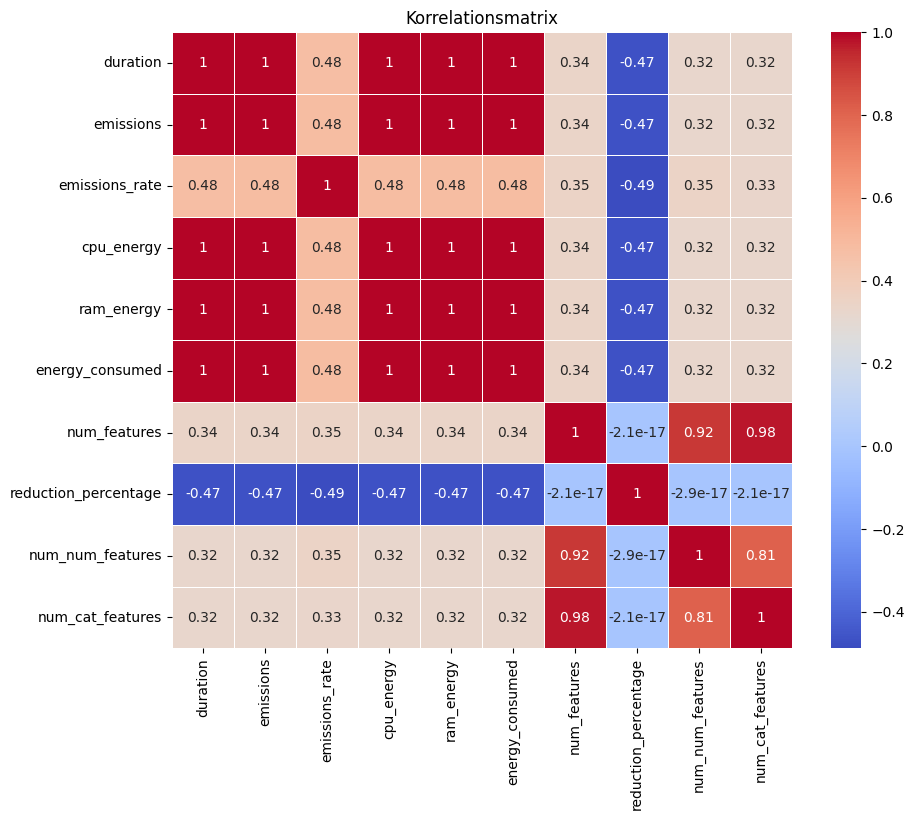

In [11]:
visualize_correlation_matrix(xgb_df)

### Logistic Regression

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


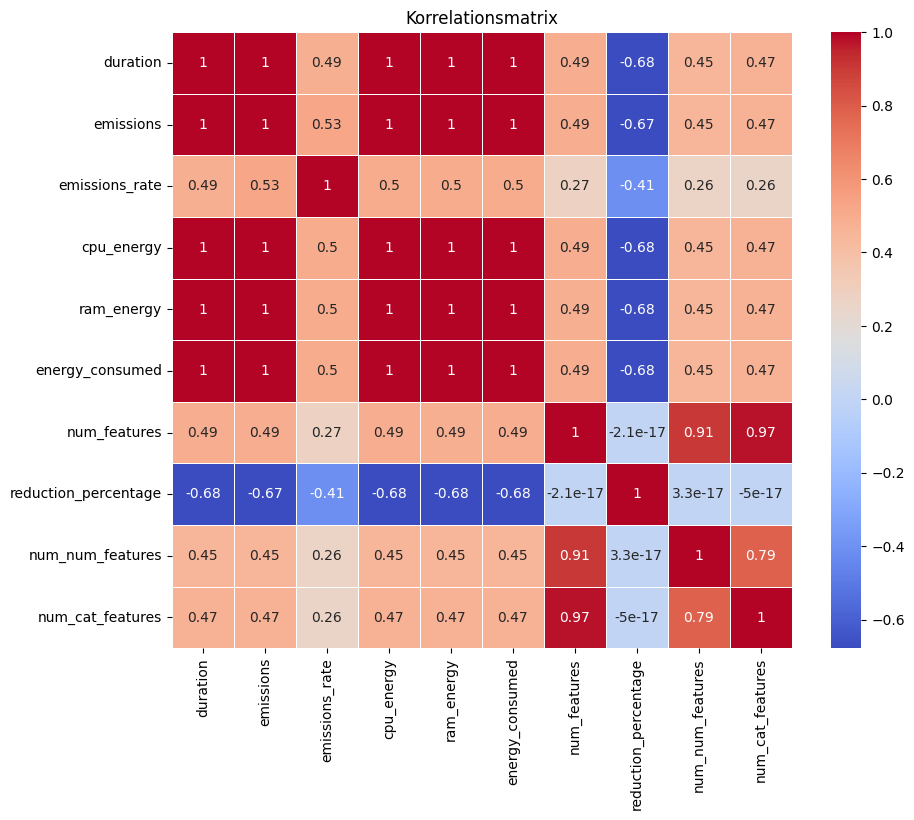

In [12]:
visualize_correlation_matrix(logistic_regression_df)

### KNN

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


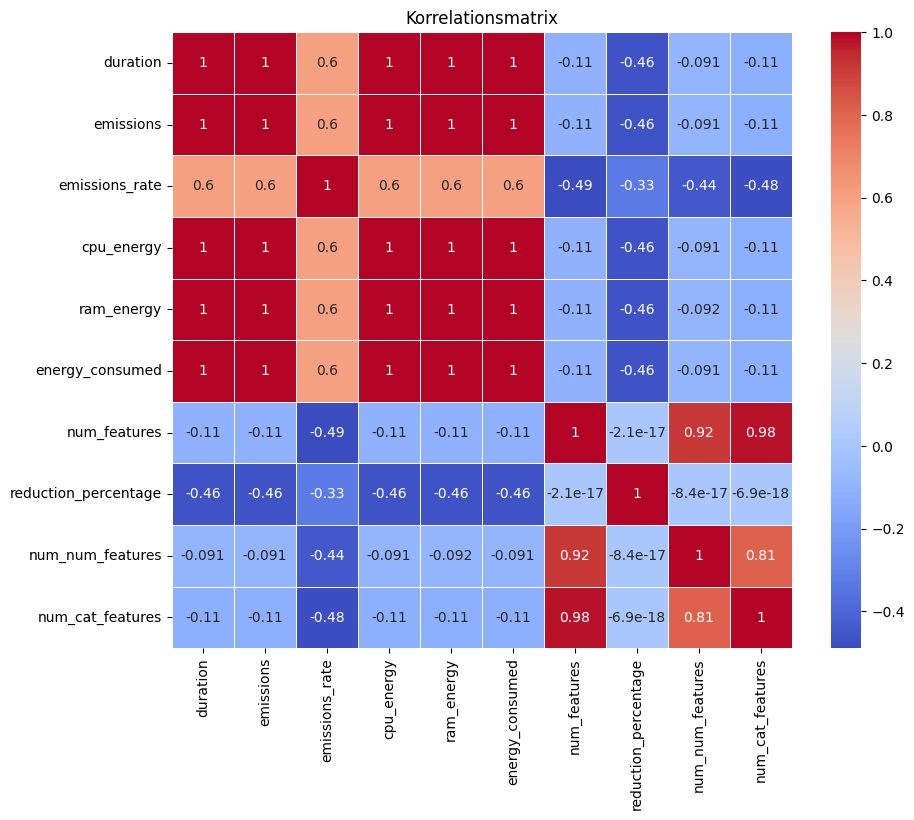

In [13]:
visualize_correlation_matrix(knn_df)

### Gaussian

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


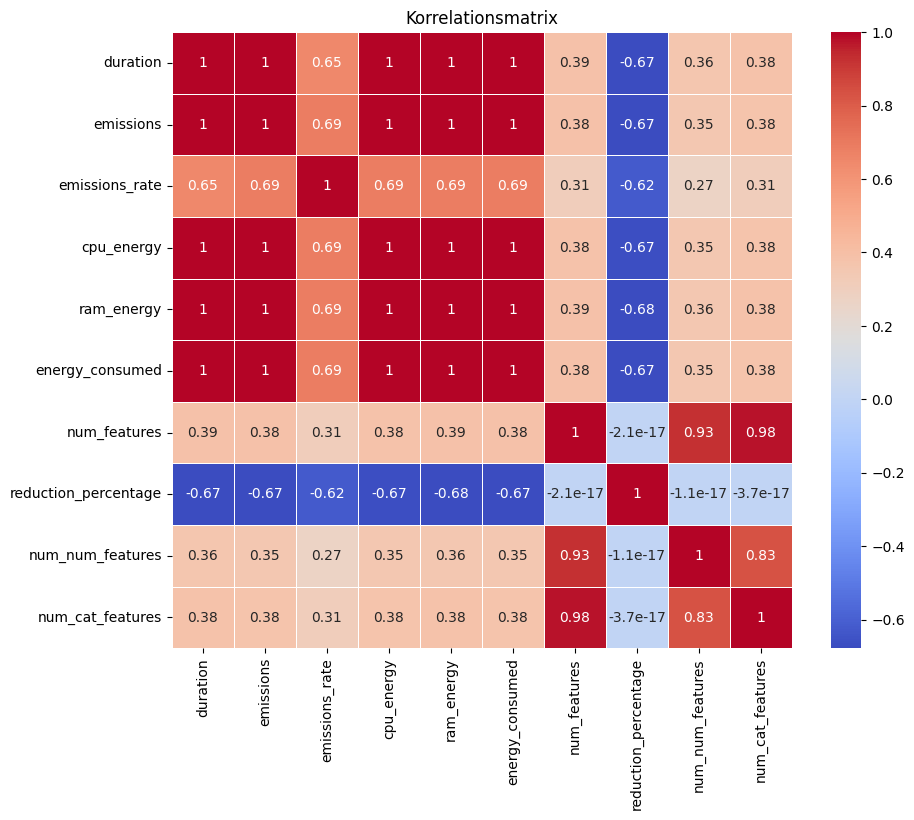

In [14]:
visualize_correlation_matrix(gaussian_nb_df)

### Decision Tree

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


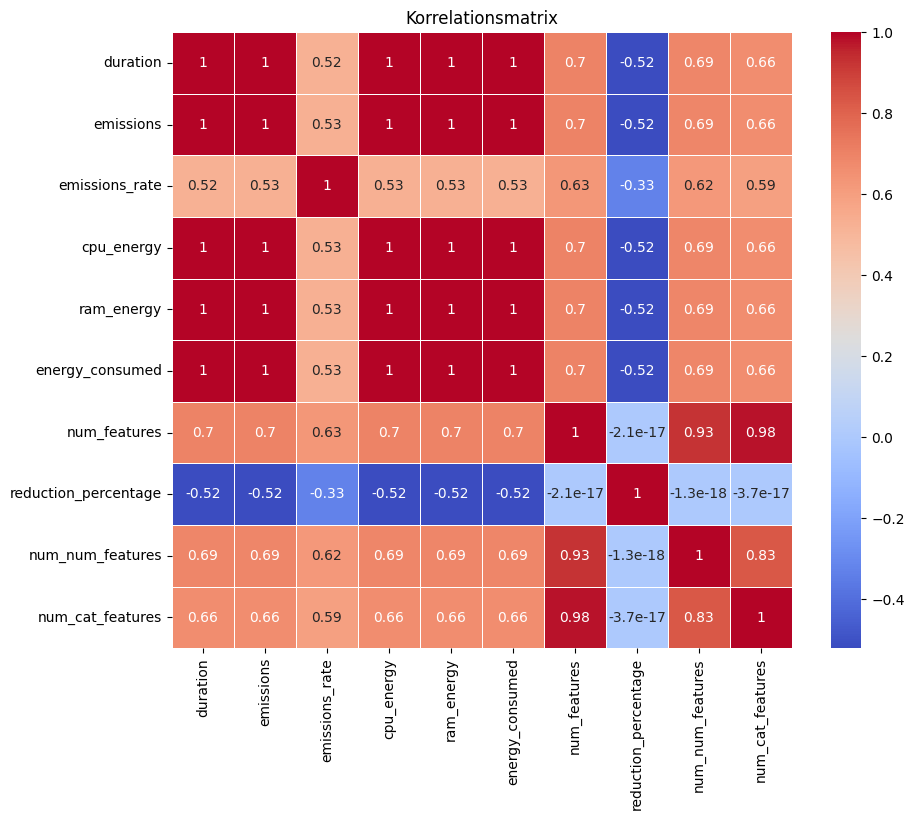

In [15]:
visualize_correlation_matrix(decision_tree_df)

# Versuch 1 - Seperate Algorithmen


In [16]:
# Funktion zum Model trainieren

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



def train_model(df):
  '''
  Für die seperaten Algorithmen kann der Modelname entfernt werden, da dieser
  keinen Einfluss haben wird
  '''
  X = df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
  y = df['energy_consumed']

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  regressor = LinearRegression()
  regressor.fit(X_train, y_train)

  return regressor, X_train, X_test, y_train, y_test

In [17]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Funktion zum Ergebnisse predicten
def get_predictions(regressor, X_test, X_train, y_test):
  predictions = regressor.predict(X_test)

  plt.scatter(y_test, predictions)
  regression_line = np.polyfit(y_test, predictions, 1)
  plt.plot(y_test, np.polyval(regression_line, y_test), color='red')
  plt.show()

  residuals = y_test - predictions
  plt.scatter(predictions, residuals)
  plt.axhline(y=0, color='red', linestyle='--')
  plt.xlabel("Vorhersagen")
  plt.ylabel("Residuen")
  plt.title("Residualplot")

  plt.show()

  r2 = r2_score(y_test, predictions)
  rmse = mean_squared_error(y_test, predictions, squared=False)
  mae = mean_absolute_error(y_test, predictions)
  mse = mean_squared_error(y_test, predictions)

  print(f'R2 Score: {r2}')
  print(f'RMSE: {rmse}')
  print(f'MAE: {mae}')
  print(f'MSE: {mse}')

In [18]:
!pip install ludwig

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 6.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.2/682.2 kB 12.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.2/519.2 kB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.1/98.1 kB 13.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.0/232.0 kB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 19.5 MB/s eta 0:0

In [19]:
from ludwig.api import LudwigModel

def train_ludwig_model(df):
    model_definition = {
        'input_features': [
            {'name': 'num_features', 'type': 'numerical'},
            {'name': 'reduction_percentage', 'type': 'numerical'},
            {'name': 'num_num_features', 'type': 'numerical'},
            {'name': 'num_cat_features', 'type': 'numerical'},
        ],
        'output_features': [
            {'name': 'energy_consumed', 'type': 'numerical'}
        ]
    }

    model = LudwigModel(model_definition)
    train_stats = model.train(df)

    return model



/usr/local/lib/python3.10/dist-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


/usr/local/lib/python3.10/dist-packages/bitsandbytes/libbitsandbytes_cpu.so: undefined symbol: cadam32bit_grad_fp32


In [20]:
import matplotlib.pyplot as plt

def get_ludwig_predictions(model, df):
    predictions_dict = model.predict(df)[0]  # Access the first element of the tuple (predictions)

    # Extract the values from the dictionary
    predictions = predictions_dict['energy_consumed_predictions'].values

    # Print lengths of arrays
    #print("Length of actual values:", len(df['energy_consumed']))
    #print("Length of predicted values:", len(predictions))

    # Scatter plot of Actual vs Predicted
    plt.scatter(df['energy_consumed'], predictions)
    plt.xlabel("Actual Energy Consumed")
    plt.ylabel("Predicted Energy Consumed")
    plt.title("Actual vs Predicted Energy Consumption")
    plt.show()

    return predictions


## Random Forest

In [76]:
# Assuming your target variable is 'energy_consumed'
X = random_forest_df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
y = random_forest_df['energy_consumed']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine X_train and y_train to include the target variable
train_data = X_train.copy()
train_data['energy_consumed'] = y_train

# Combine X_test and y_test to include the target variable for testing
test_data = X_test.copy()
test_data['energy_consumed'] = y_test


In [80]:
ludwig_model_rdf = train_ludwig_model(train_data)

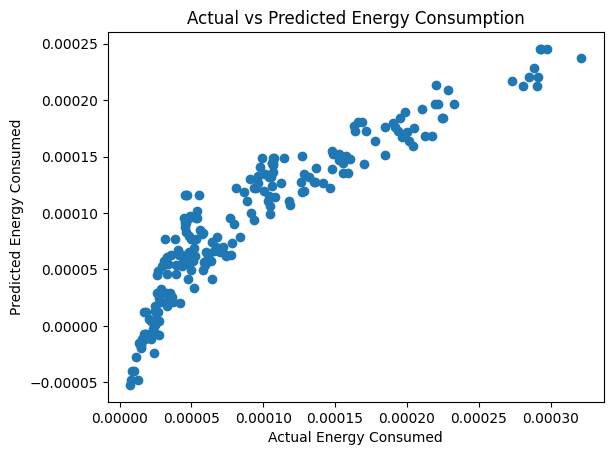

In [81]:
ludwig_predictions = get_ludwig_predictions(ludwig_model_rdf, test_data)

## XGB

In [56]:
# Assuming your target variable is 'energy_consumed'
X = xgb_df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
y = xgb_df['energy_consumed']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine X_train and y_train to include the target variable
train_data = X_train.copy()
train_data['energy_consumed'] = y_train

# Combine X_test and y_test to include the target variable for testing
test_data = X_test.copy()
test_data['energy_consumed'] = y_test


In [57]:
ludwig_model_xgb = train_ludwig_model(train_data)

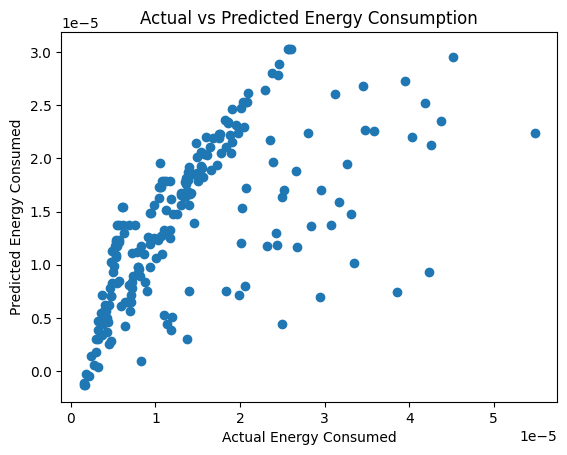

In [58]:
ludwig_predictions = get_ludwig_predictions(ludwig_model_xgb, test_data)

## Logistic Regression

In [60]:
# Assuming your target variable is 'energy_consumed'
X = logistic_regression_df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
y = logistic_regression_df['energy_consumed']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine X_train and y_train to include the target variable
train_data = X_train.copy()
train_data['energy_consumed'] = y_train

# Combine X_test and y_test to include the target variable for testing
test_data = X_test.copy()
test_data['energy_consumed'] = y_test


In [61]:
ludwig_model_lr = train_ludwig_model(train_data)

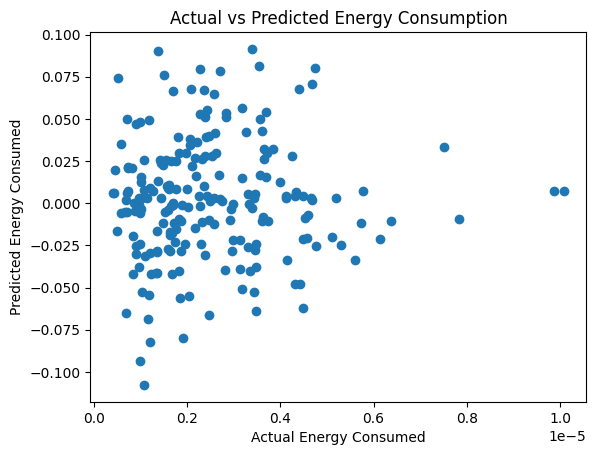

In [62]:
ludwig_predictions = get_ludwig_predictions(ludwig_model_lr, test_data)

## KNN

In [63]:
# Assuming your target variable is 'energy_consumed'
X = knn_df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
y = knn_df['energy_consumed']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine X_train and y_train to include the target variable
train_data = X_train.copy()
train_data['energy_consumed'] = y_train

# Combine X_test and y_test to include the target variable for testing
test_data = X_test.copy()
test_data['energy_consumed'] = y_test


In [64]:
ludwig_model_knn = train_ludwig_model(train_data)

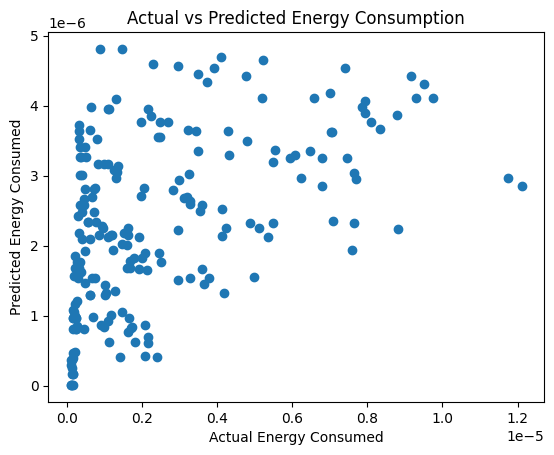

In [65]:
ludwig_predictions = get_ludwig_predictions(ludwig_model_knn, test_data)

## Gaussian

In [67]:
# Assuming your target variable is 'energy_consumed'
X = gaussian_nb_df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
y = gaussian_nb_df['energy_consumed']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine X_train and y_train to include the target variable
train_data = X_train.copy()
train_data['energy_consumed'] = y_train

# Combine X_test and y_test to include the target variable for testing
test_data = X_test.copy()
test_data['energy_consumed'] = y_test


In [68]:
ludwig_model_gnb = train_ludwig_model(train_data)

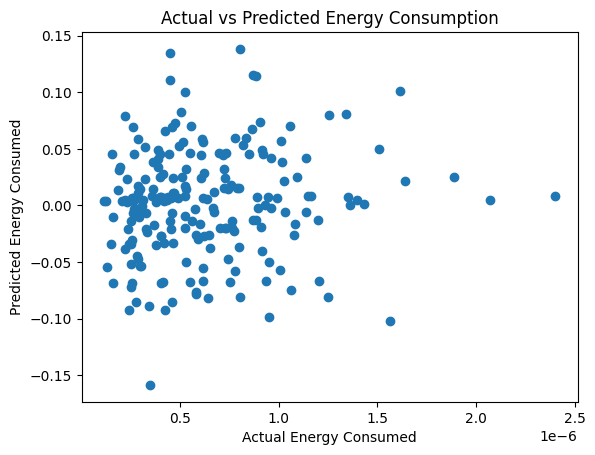

In [69]:
ludwig_predictions = get_ludwig_predictions(ludwig_model_gnb, test_data)

## Decision Tree

In [70]:
# Assuming your target variable is 'energy_consumed'
X = decision_tree_df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
y = decision_tree_df['energy_consumed']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine X_train and y_train to include the target variable
train_data = X_train.copy()
train_data['energy_consumed'] = y_train

# Combine X_test and y_test to include the target variable for testing
test_data = X_test.copy()
test_data['energy_consumed'] = y_test


In [71]:
ludwig_model = train_ludwig_model(train_data)

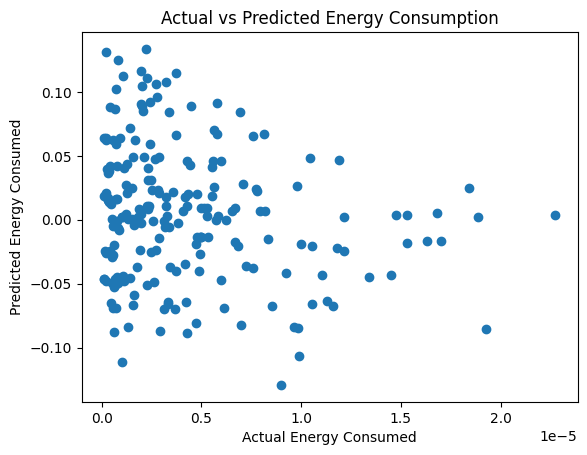

In [72]:
ludwig_predictions = get_ludwig_predictions(ludwig_model, test_data)

# Versuch 2 - Alle Algorithmen